# 03 — Grid Snapping and the Feistel PRP

## Act 1: Grid Snapping

After projecting (lat, lon) to (x, y) in metres, we quantise to the nearest 250 m grid tile:

```
qx = round(x / bin)     qy = round(y / bin)
rx = x - qx * bin       ry = y - qy * bin
```

The residual `(rx, ry)` is always in **(-125, +125) m** — the full sub-tile precision of the original GPS fix. Storing `(qx, qy)` in plain text would reveal the 250 m tile; that is why we need to shuffle it.

## Act 2 Preview: The Permutation Requirement

We need to map every tile index `(qx, qy)` to an encrypted index `(qxp, qyp)` such that:
1. No two tiles map to the same encrypted tile (injectivity).
2. The mapping is reversible (surjectivity over the same finite set).
3. The mapping is keyed and computationally indistinguishable from random.

A keyed bijection on a finite set is a **<abbr title="A keyed scrambling function: maps every tile index to a unique output index, reversible only with the key, and indistinguishable from a random shuffle to anyone without it." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">pseudorandom permutation (PRP)</abbr>**. The Feistel network construction guarantees this.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Pipeline step 2 of 4 — Grid snapping and Feistel PRP</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:500;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#dff0ee;color:#3d7a71;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:500;font-size:13px;">③ Lock</div></div>
    <div style="background:#dff0ee;color:#3d7a71;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:500;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Define** tile quantisation and state the purpose of `bin_size_m` in converting projected coordinates to integer tile indices.
2. **Describe** the Feistel round structure and explain why alternating left–right mixing guarantees a bijection over the tile-index domain.
3. **Demonstrate** the PRP encryption step manually for a Broadwick Street pump coordinate and verify the result matches `_prp_encrypt`.
4. **Differentiate** between the plaintext tile indices `(qx, qy)` and the PRP-shuffled indices `(qxp, qyp)` stored in the encrypted record.
5. **Construct** a rejection-sampling argument for why naive `hash % M` produces a biased frequency distribution, and explain how the cutoff-based rejection-sampling approach achieves exactly uniform output over the tile-index range `[0, M)`.

![A four-panel comic titled 'From Exact Location to Tile Abstraction.' Panel 1: A Privacy Engineer (bearded Victorian man with a pointer) stands beside a wall map labelled 'Soho, London Cholera Cases, September 1854', covered in red dots. An Epidemiologist (woman) looks on. Speech bubble: 'Each red dot is a household-precise but risky to share.' Caption: 'Raw points reveal exact locations.' Panel 2: The same pair examine a square grid overlaid on the map. Blue filled squares mark tiles with cases; white squares have none. Legend: one tile = 200m x 200m. Engineer: 'Instead of exact points, we assign each case to its tile.' Epidemiologist: 'So we still know where the deaths are...' Caption: 'We overlay a grid and keep only the tile.' Panel 3: The pair stand together. Engineer: 'We no longer know the exact household. But we still see meaningful patterns at the neighbourhood scale.' Caption: 'This reduces precision... Abstraction removes exactness, not insight.' Panel 4: A three-step diagram — Exact Points (red dots on map) arrow to Tile Assignment / Abstraction (dots snapped to grid squares) arrow to Ready for Shuffling / PRP Permutation (arrows indicating rearrangement). A shield badge reads: 'Abstraction is the first step in protecting spatial identity. We keep the signal, and reduce the risk.' Caption: '...and prepares the data for privacy-preserving transforms.'](images/NB03-C1.png)


In [1]:
import math
import struct
import hashlib
import secrets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from map_encryption import (
    _project, _unproject, _grid_range, _prp_encrypt, _prp_decrypt,
    _prf_upto, SchemeParams, _R_EARTH,
)

def metres_to_deg(spread_m, at_lat):
    lat_deg = spread_m / 111_320
    lon_deg = spread_m / (111_320 * math.cos(math.radians(at_lat)))
    return lat_deg, lon_deg

params = SchemeParams()
BIN = params.bin_size_m
CENTER_LAT, CENTER_LON = 51.513341, -0.136668  # Broadwick Street pump, Soho, London (1854 cholera outbreak)

In [2]:
x_ts, y_ts = _project(CENTER_LAT, CENTER_LON)
qx = int(round(x_ts / BIN))
qy = int(round(y_ts / BIN))
rx = x_ts - qx * BIN
ry = y_ts - qy * BIN

print(f'Broadwick Street pump projection:')
print(f'  x = {x_ts:.3f} m,  y = {y_ts:.3f} m')
print(f'  qx = {qx},  qy = {qy}')
print(f'  rx = {rx:.4f} m,  ry = {ry:.4f} m')

assert abs(rx) < 125, f'rx={rx} outside tile half-width'
assert abs(ry) < 125, f'ry={ry} outside tile half-width'
print('Residual is within tile half-width: OK')

Broadwick Street pump projection:
  x = -15213.812 m,  y = 6712605.101 m
  qx = -61,  qy = 26850
  rx = 36.1878 m,  ry = 105.1006 m
Residual is within tile half-width: OK


In [3]:
min_q, M = _grid_range(BIN)
print(f'Grid range: min_q = {min_q},  M = {M}')
print(f'Total cells: M^2 = {M**2:,}')

print('\n5x5 grid of (qx, qy) tiles near Broadwick Street pump and their back-projected coords:')
print(f'{"(qx,qy)":<20} {"lat":>10} {"lon":>12}')
for dqy in range(-2, 3):
    for dqx in range(-2, 3):
        tqx, tqy = qx + dqx, qy + dqy
        tlat, tlon = _unproject(tqx * BIN, tqy * BIN)
        print(f'  ({tqx},{tqy})            {tlat:>10.6f} {tlon:>12.6f}')

Grid range: min_q = -80151,  M = 160302
Total cells: M^2 = 25,696,731,204

5x5 grid of (qx, qy) tiles near Broadwick Street pump and their back-projected coords:
(qx,qy)                     lat          lon
  (-63,26848)             51.509958    -0.141485
  (-62,26848)             51.509958    -0.139239
  (-61,26848)             51.509958    -0.136993
  (-60,26848)             51.509958    -0.134747
  (-59,26848)             51.509958    -0.132502
  (-63,26849)             51.511356    -0.141485
  (-62,26849)             51.511356    -0.139239
  (-61,26849)             51.511356    -0.136993
  (-60,26849)             51.511356    -0.134747
  (-59,26849)             51.511356    -0.132502
  (-63,26850)             51.512753    -0.141485
  (-62,26850)             51.512753    -0.139239
  (-61,26850)             51.512753    -0.136993
  (-60,26850)             51.512753    -0.134747
  (-59,26850)             51.512753    -0.132502
  (-63,26851)             51.514151    -0.141485
  (-62,26

## Why the Mapping Must Be a Bijection

If two tiles `(qx1, qy1)` and `(qx2, qy2)` mapped to the same encrypted tile `(qxp, qyp)`, decryption would be ambiguous — we would not know which original tile to recover. A PRP avoids this by construction: it is a **<abbr title="A one-to-one mapping with no collisions: every input maps to exactly one unique output, and every output came from exactly one input. Required so decryption is unambiguous." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>bijection</strong></abbr>** (one-to-one and onto) on the tile index set.

**<abbr title="A construction that builds a reversible scrambling function from any mixing function. Even a non-invertible F produces an invertible round — that is the Feistel trick." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>Feistel</strong></abbr> round structure** (one round):
```
L_new = (L + F(R, key, tweak, round)) mod M
(L, R) = (R, L_new)    # swap
```
Regardless of `F`, reversing the swap and then subtracting `F(R, ...)` recovers the original. Even a non-invertible `F` produces an invertible round — that is the Feistel trick. After ≥ 4 rounds the composition is a PRP (Luby & Rackoff, 1988).

## Rejection Sampling for Unbiased PRF Output

Naive `hash % M` is **biased** when `2^256 mod M ≠ 0`. Suppose `2^256 = k*M + r` with `r > 0`. Values in `[0, r)` are hit `k+1` times; values in `[r, M)` only `k` times. Over millions of records, this creates a **<abbr title="A side-channel where slightly non-uniform output frequencies reveal a detectable pattern — an attacker who sees many encrypted tile indices can identify which appear slightly more often." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>frequency fingerprint</strong></abbr>**: an attacker observing encrypted tile indices can distinguish slightly-more-frequent values from slightly-less-frequent ones.

**<abbr title="A technique for unbiased uniform output: generate a candidate value, discard it if it falls in a biased range, and retry until an accepted value is found." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;"><strong>Rejection sampling</strong></abbr>** fixes this:
```
cutoff = floor(2^256 / M) * M
loop:
    h = BLAKE2s(key, data + counter)
    val = int.from_bytes(h, 'big')
    if val < cutoff: return val % M
    counter += 1
```
Rejection probability `< M / 2^256 ≈ 6×10⁻⁷²` — virtually impossible. The result is exactly uniform over `[0, M)`.

In [4]:
min_q, M = _grid_range(BIN)
fixed_key = hashlib.blake2s(b'nb03-prf-demo', digest_size=32).digest()

cutoff = ((1 << 256) // M) * M
print(f'M = {M},  cutoff = {cutoff}')
print()

for i in range(3):
    data = struct.pack('>I', i)
    h = hashlib.blake2s(key=fixed_key, digest_size=32)
    h.update(data + struct.pack('>I', 0))
    raw = int.from_bytes(h.digest(), 'big')
    result = _prf_upto(fixed_key, data, M)
    accepted = raw < cutoff
    print(f'input={i}: raw_hash={raw} (accepted={accepted}), result={result}')
    assert 0 <= result < M, f'result {result} out of range [0, {M})'

print('\nAll results in [0, M): OK')

M = 160302,  cutoff = 115792089237316195423570985008687907853269984665640564039457584007913129538052

input=0: raw_hash=62063294506474534406807778697367844746765763659134447517792861568967532039976 (accepted=True), result=81864
input=1: raw_hash=95845104314074709888036525528181289095128042645880492658927600999069123810873 (accepted=True), result=78097
input=2: raw_hash=76660543974569812697702030828215209556824024407919041361775988918881059455720 (accepted=True), result=51776

All results in [0, M): OK


---
## Manual Feistel PRP Demonstration

To make the Feistel mechanics concrete, we trace the PRP encryption step by hand for the Broadwick Street tile computed in the previous cell. Each of the four rounds is unrolled, printing the PRF output `F` and the updated `(L, R)` halves after every step. The final result is then compared against `_prp_encrypt` — the library implementation — to confirm they are identical.

The Feistel network treats the tile pair `(qx, qy)` as two halves of a block cipher. A non-invertible PRF `F` drives each round, but the alternating structure guarantees the overall mapping is always invertible — that is the Feistel trick. After four rounds the result is a bijection over the full tile-index domain `[min_q, min_q + M)`.

In [5]:
test_key   = hashlib.blake2s(b'nb03-test', digest_size=32).digest()
test_tweak = b'nb03-demo'
min_q, M   = _grid_range(BIN)
N_ROUNDS   = 4

# Shift (qx, qy) into [0, M) so the Feistel arithmetic stays positive.
# L = left half (x-axis tile), R = right half (y-axis tile).
L, Rv = qx - min_q, qy - min_q
print(f'Broadwick Street tile:  qx={qx}, qy={qy}')
print(f'Shifted into [0, M):    L={L},  R={Rv}')
print()

for r in range(N_ROUNDS):
    # F: a keyed PRF over (tweak || round_index || right_half).
    # Non-invertible on its own, but the swap step makes the round reversible.
    F = _prf_upto(test_key, test_tweak + struct.pack('>II', r, Rv), M)
    L = (L + F) % M      # mix: update left half with F(right half)
    L, Rv = Rv, L        # swap: left becomes right for next round
    print(f'Round {r}: F={F:>10},  L={L:>10},  R={Rv:>10}')

# _prp_encrypt compensates for parity of rounds when reconstructing (qxp, qyp).
# For an even number of rounds (4), no extra swap is needed.
manual_qxp = L  + min_q   # shift back to original tile-index range
manual_qyp = Rv + min_q

# Cross-check: the library must produce the same shuffled indices.
lib_qxp, lib_qyp = _prp_encrypt(qx, qy, test_key, test_tweak, BIN, N_ROUNDS)
print(f'\nManual result:  qxp={manual_qxp},  qyp={manual_qyp}')
print(f'Library result: qxp={lib_qxp},  qyp={lib_qyp}')
assert (manual_qxp, manual_qyp) == (lib_qxp, lib_qyp), 'Mismatch!'
print('Manual Feistel trace matches _prp_encrypt: PASS')
print(f'Bijection confirmed: ({qx}, {qy}) maps to ({manual_qxp}, {manual_qyp}) uniquely.')


Broadwick Street tile:  qx=-61, qy=26850
Shifted into [0, M):    L=80090,  R=107001

Round 0: F=    135114,  L=    107001,  R=     54902
Round 1: F=      3643,  L=     54902,  R=    110644
Round 2: F=    123291,  L=    110644,  R=     17891
Round 3: F=    156841,  L=     17891,  R=    107183

Manual result:  qxp=-62260,  qyp=27032
Library result: qxp=-62260,  qyp=27032
Manual Feistel trace matches _prp_encrypt: PASS
Bijection confirmed: (-61, 26850) maps to (-62260, 27032) uniquely.


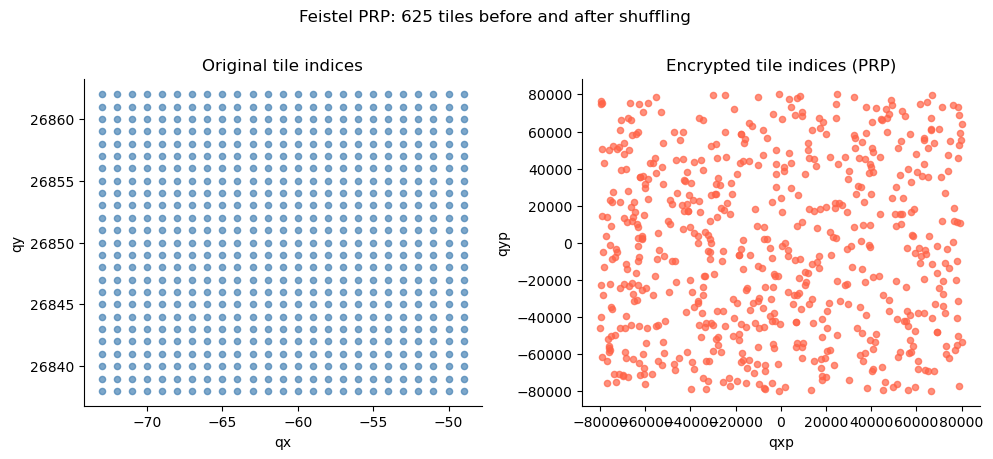

In [6]:
# PRP scatter: 25x25 = 625 tiles
prp_key   = hashlib.blake2s(b"nb03-scatter", digest_size=32).digest()
prp_tweak = b"nb03-demo"

orig_qx, orig_qy, enc_qxp, enc_qyp = [], [], [], []
for dqx in range(-12, 13):
    for dqy in range(-12, 13):
        tqx, tqy = qx + dqx, qy + dqy
        tqxp, tqyp = _prp_encrypt(tqx, tqy, prp_key, prp_tweak, BIN, 10)
        orig_qx.append(tqx);  orig_qy.append(tqy)
        enc_qxp.append(tqxp); enc_qyp.append(tqyp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.scatter(orig_qx, orig_qy, c="steelblue", s=20, alpha=0.7)
ax1.set_title("Original tile indices"); ax1.set_xlabel("qx"); ax1.set_ylabel("qy")

ax2.scatter(enc_qxp, enc_qyp, c="tomato", s=20, alpha=0.7)
ax2.set_title("Encrypted tile indices (PRP)"); ax2.set_xlabel("qxp"); ax2.set_ylabel("qyp")

fig.suptitle("Feistel PRP: 625 tiles before and after shuffling", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()


**Figure 3a.** Scatter plot of 625 tile indices before (blue) and after (orange) Feistel PRP permutation over a 25 × 25 grid, illustrating that the bijection redistributes tiles pseudo-randomly while preserving the full index domain.

In [7]:
import pandas as pd
import folium

deaths = pd.read_csv('data/cholera_deaths.csv')

# Show 250 actual death locations and their snapped 250 m tile centres.
# Deaths are tightly clustered around the Broadwick Street pump — the 250 m bins
# capture neighbourhood-level precision while coarsening exact addresses.
rows = []
for _, row in deaths.iterrows():
    lat, lon = row['LAT'], row['LON']
    x_i, y_i = _project(lat, lon)
    tqx = int(round(x_i / BIN))
    tqy = int(round(y_i / BIN))
    snap_lat, snap_lon = _unproject(tqx * BIN, tqy * BIN)
    rows.append({'lat': lat,      'lon': lon,      'type': 'original'})
    rows.append({'lat': snap_lat, 'lon': snap_lon, 'type': 'snapped (tile centre)'})

colors = {'original': 'steelblue', 'snapped (tile centre)': 'orange'}
m = folium.Map(location=[51.513, -0.136], zoom_start=15, tiles='cartodbpositron')
for row in rows:
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colors[row['type']],
        fill=True,
        fill_color=colors[row['type']],
        fill_opacity=0.7,
        tooltip=row['type'],
    ).add_to(m)
m


**Figure 3b.** Folium map of all 250 cholera death locations snapped to their nearest 250 m tile centres, centred on the Broadwick Street pump in Soho.

## What Snapping + PRP Protect — and Don't

**Protected by snapping:** GPS precision is coarsened to ±125 m; even knowing (qx, qy), an adversary cannot determine the exact position within the tile.

**Protected by PRP:** Without the PRP key, (qxp, qyp) reveals no information about which tile was originally visited — including which country or continent.

**Not yet protected:** The residual `(rx, ry)` is still in plaintext at this stage. It carries the full within-tile precision of the original GPS fix. NB04 shows how <abbr title="Authenticated Encryption with Associated Data — a single operation that both locks data (confidentiality) and produces an authentication tag covering additional unencrypted context (integrity). Any tampering with the ciphertext, nonce, or associated data is detected." style="background:#efefef;border-radius:3px;padding:0 2px;cursor:help;text-decoration:none;">AEAD</abbr> encryption seals this final piece of information.

![A three-panel comic titled 'Stable Tile IDs Can Reveal Geography.' Panel 1: An adversary (Victorian man in a top hat, seated at a desk) compares a 'Public Hotspot Map (Cholera Cases)' on the left with a table of 'Observed Data (Raw Tile IDs)' showing numbers such as 17, 42, 8, 3. Speech bubble: 'These numbered tiles line up with the outbreak map.' Caption: 'An adversary compares tiles.' Panel 2: The adversary and a colleague study a grid map labelled 'Inferred from Raw Tile IDs' showing a red hotspot cluster in the centre. Speech bubble: 'Even without exact addresses, the pattern still reveals the hotspot.' Caption: 'They recognize a hotspot region.' Panel 3: A Privacy Engineer (standing, in waistcoat) presents a new table 'Observed Data (Permuted Tile IDs)' with scrambled numbers such as 91, 14, 55, 27, 63. Speech bubble: 'We scramble the spatial identities before release.' Colleague: 'Now the hotspot can\'t be linked to a real place.' A padlock icon with caption: 'Same patterns, but IDs no longer reveal geography.' Caption: 'A data engineer introduces permutation.' Bottom banner with warning triangle: 'Stable tile identities can become geographic fingerprints. Permutation weakens direct geographic inference.' Shield icon at right.](images/NB03-C2.png)


## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London. — Source of the 1854 Soho cholera death and pump location dataset used throughout these notebooks.
- **Luby, M., & Rackoff, C.** (1988). How to construct pseudorandom permutations from pseudorandom functions. *SIAM Journal on Computing, 17*(2), 373–386. https://doi.org/10.1137/0217022 — Proof that ≥ 4 Feistel rounds over a pseudorandom function produce a pseudorandom permutation. Foundation for the tile-shuffle PRP in this library.
- **Aumasson, J.-P., Neves, S., Wilcox-O'Hearn, Z., & Winnerlein, C.** (2013). BLAKE2: simpler, smaller, fast as MD5. *ACNS 2013*, LNCS 7954, 119–135. https://doi.org/10.1007/978-3-642-38980-1_8 — BLAKE2s is the PRF used for the Feistel round function F in this notebook.

## Glossary

| Term | Definition |
|------|-----------|
| **Grid snapping** | Rounding projected (x, y) coordinates to the nearest multiple of `bin_size_m` to assign each point to a tile. |
| **Tile** | A square cell of side `bin_size_m` (default 250 m) in projected space; the unit of spatial resolution for the encryption scheme. |
| **Tile index (qx, qy)** | Integer coordinates identifying a tile; computed as `round(x / bin_size_m)`, `round(y / bin_size_m)`. |
| **Residual (rx, ry)** | The sub-tile offset `(x − qx·bin, y − qy·bin)`; always within ±125 m of the tile centre; carries full GPS precision. |
| **Pseudorandom permutation (PRP)** | A keyed bijection on a finite set that is computationally indistinguishable from a uniformly random permutation; used here to shuffle tile indices. |
| **Feistel network** | A construction that builds an invertible function (a PRP) from any non-invertible round function; guarantees reversibility regardless of the round function. |
| **Bijection** | A function that is both injective (no two inputs share an output) and surjective (every output has an input); required so that decryption is unambiguous. |
| **Pseudorandom function (PRF)** | A keyed function whose outputs are computationally indistinguishable from random; used as the Feistel round function via BLAKE2s. |
| **Rejection sampling** | A technique to produce a uniform random value in `[0, M)` from a hash output by discarding values ≥ `⌊2²⁵⁶/M⌋·M`, eliminating modular bias. |
| **Shuffled tile index (qxp, qyp)** | The PRP-encrypted tile index stored in the record; reveals no geographic information without `prp_key`. |

![A four-panel comic with bottom banner. Panel 1: Three characters — a Privacy Engineer, an Epidemiologist, and a colleague — stand before a wall map labelled 'Soho, London Cholera Cases, September 1854' showing street grid, water pump marker, and red cholera death dots. Caption: 'Original city blocks preserve geographic meaning.' Panel 2: The group examines a 5x5 grid of abstract coordinate pairs: (0,0), (1,0), (2,0)... through (4,4). Speech bubble: 'We convert neighbourhoods into abstract spatial indices.' Caption: 'We represent the city with abstract spatial indices.' Panel 3: The same grid now shows permuted coordinates — e.g. (3,2), (0,4), (4,1), (1,3) — with a key icon visible. Speech bubble: 'Permutation is reversible with the secret key, but unpredictable to others.' Caption: 'We permute the spatial identities. The spatial identities have been permuted.' Panel 4: A split view — Original Map (dot cluster) with a not-equal sign beside a Shuffled Coordinates table. The adversary (Victorian man in top hat, seated) has a question mark speech bubble: 'I can still see patterns... but I no longer know where they belong.' Caption: 'An adversary loses direct geographic interpretation.' Bottom banner with shield and padlock icons: 'Spatial meaning has been permuted. The structure survives. The geography does not.'](images/NB03-C3.png)
